In [10]:
import numpy as np
import matplotlib.pyplot as plt

from hypyp.fnirs import FNIRSRecording, FNIRSDyad
from hypyp.utils import Task


Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]
Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]


/tmp/ipykernel_398531/642089674.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


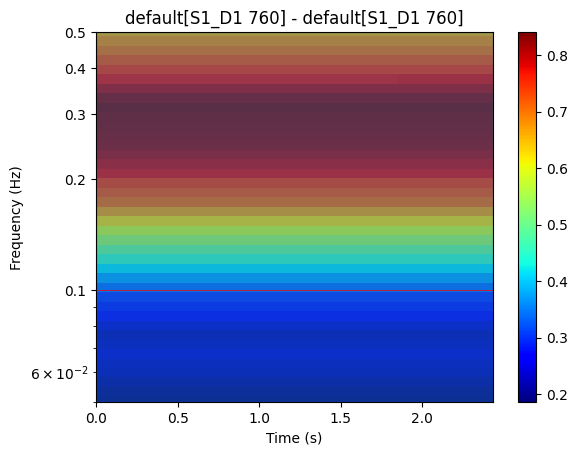

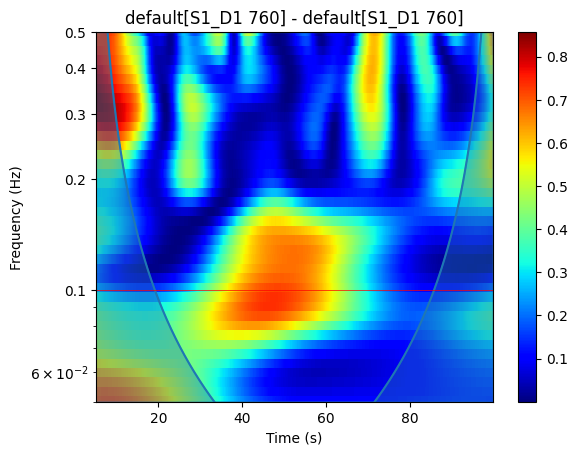

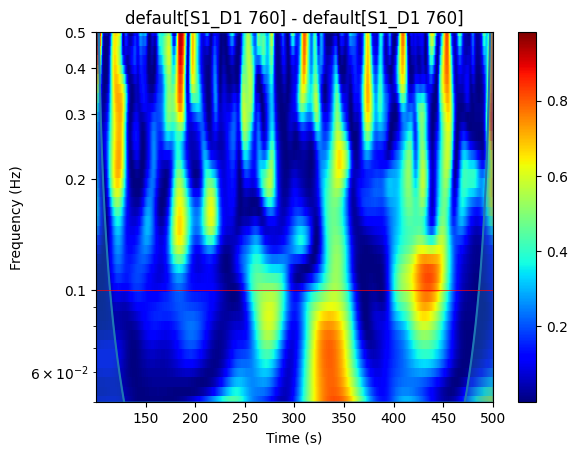

In [11]:

snirf_file1 = '../data/NIRS/DCARE_02_sub1.snirf'
snirf_file2 = '../data/NIRS/DCARE_02_sub2.snirf'
tasks = [
    Task('task1', onset_time=0, duration=500),
]
# Use the same file for the 2 subjects
s1 = FNIRSRecording(tasks=tasks).load_file(snirf_file1)
s2 = FNIRSRecording(tasks=tasks).load_file(snirf_file2)
dyad = FNIRSDyad(s1, s2)

epochs = s1.get_epochs_for_task('task1')
data = epochs.get_data()
# Set some values to NaN to split in 3 sections
data[0, 0, 20:40] = np.nan
t = int(100*epochs.info['sfreq'])
data[0, 0, t:t+1] = np.nan
epochs._data = data
dyad.compute_wtcs(ch_match=epochs.ch_names[0], frequency_cuts=[0.1, 0.05], downsample=None)
df = dyad.df

_ = dyad.wtcs[0].plot()
_ = dyad.wtcs[1].plot()
_ = dyad.wtcs[2].plot()

[(0, 28), (28, 40)]
[(0, 28), (28, 39), (39, 40)]
[(0, 28), (28, 40)]
[(0, 28), (28, 40)]
[(0, 28), (28, 39), (39, 40)]
[(0, 28), (28, 40)]


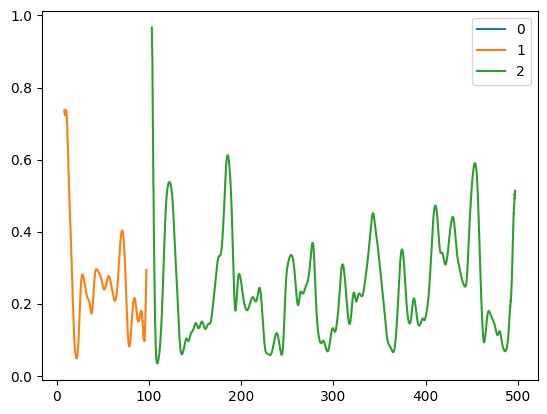

In [12]:
time_series = [wtc.get_as_time_series(window_size=1) for wtc in dyad.wtcs]

for wtc in dyad.wtcs:
    y = wtc.get_as_time_series(window_size=1)[0]
    x = wtc.times

    plt.plot(x, y, label=wtc.section_id)

plt.legend()
plt.show()


[(0, 28), (28, 40)]
(2, 20)
[(0, 28), (28, 39), (39, 40)]
(3, 741)
[(0, 28), (28, 40)]
(2, 3125)


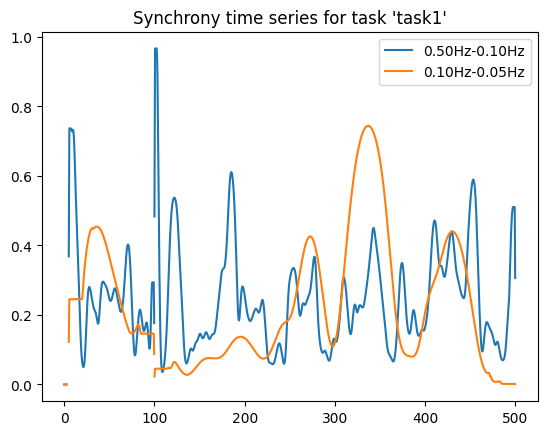

In [ ]:
for task, ts in dyad.get_synchrony_time_series().items():
    for i in range(ts.shape[0]):
        x = np.arange(ts.shape[1]) * dyad.wtcs[0].dt
        plt.plot(x, ts[i,:], label=dyad.wtcs[0].p_ranges_str[i])

    plt.title(f"Synchrony time series for '{task}'")
    plt.legend()
    plt.show()
